In [1]:
%%capture
## [TEMPLATE BEGIN]
## おまじない：実行中のノートブック名からOUTPUT_DIRを決めるコード
from pathlib import Path
from IPython import get_ipython; ip = get_ipython()
if '__vsc_ipynb_file__' in ip.user_ns:
    ## VS Codeで実行されている場合
    THIS_NOTEBOOK_PATH = Path(ip.user_ns['__vsc_ipynb_file__'])
else:
    !pip install ipynbname
    import ipynbname; THIS_NOTEBOOK_PATH = Path(ipynbname.path())
    if "%2F" in THIS_NOTEBOOK_PATH.stem:
        ## Google Colabで実行されている場合
        colab_ip = %system hostname -I   # uses colab magic to get list from bash
        colab_ip = colab_ip[0].strip()   # returns "172.28.0.12"
        colab_port = 9000                # could use 6000, 8080, or 9000
        import requests
        filename = requests.get(f"http://{colab_ip}:{colab_port}/api/sessions").json()[0]["name"]
        THIS_NOTEBOOK_PATH = Path(filename)
    else:
        ## それ以外の場合
        THIS_NOTEBOOK_PATH = THIS_NOTEBOOK_PATH

OUTPUT_DIR = Path("figures") / THIS_NOTEBOOK_PATH.stem
## [TEMPLATE END]

In [2]:
print("File output directory:", OUTPUT_DIR)
# Create the output directory if it does not exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

File output directory: figures/_ridge_least_squares_classification


Accuracy: 100.00%


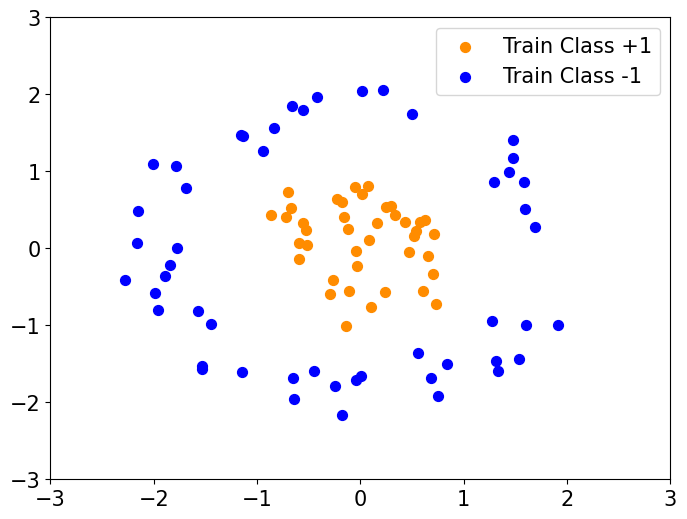

Train data points only plot saved to: figures/_ridge_least_squares_classification/classification_points_only_train_plot.png


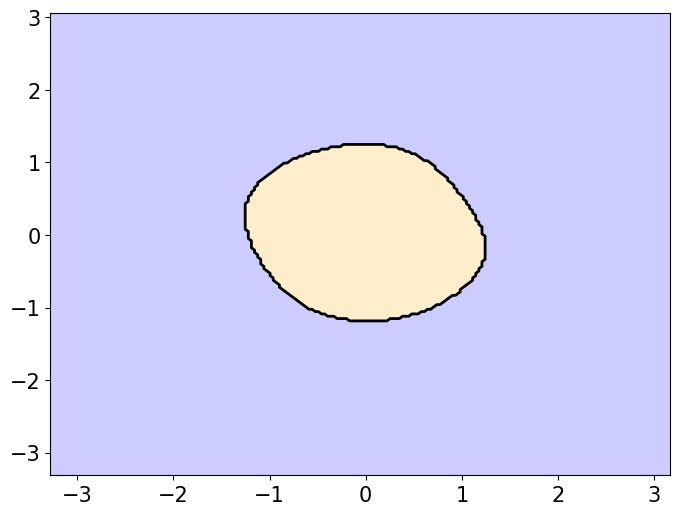

Contour plot saved to: figures/_ridge_least_squares_classification/classification_contour_plot.png


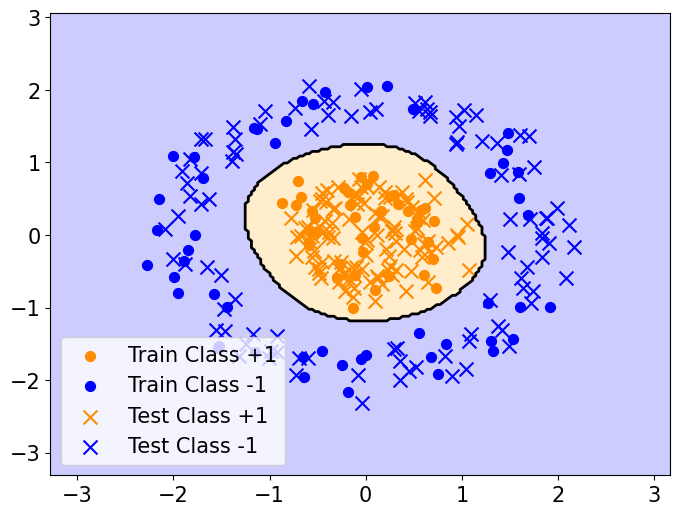

Contour with data points plot saved to: figures/_ridge_least_squares_classification/classification_contour_with_points_plot.png


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from pathlib import Path

# カラーパレット
colors = {
    "white": "#FFFFFF",
    "light_gray": "#D3D3D3",
    "gray": "#808080",
    "black": "#000000",
    "green": "#008000",
    "blue": "#0000FF",
    "light_blue": "#ADD8E6",
    "yellow": "#FFFF00",
    "orange": "#FFA500",
    "dark_orange": "#FF8C00",
    "purple": "#800080"
}

# パラメータ設定
lambda_param = 1.0  # 正則化パラメータ
n_samples = 300  # サンプル数

# グローバルで定義された出力ディレクトリ (OUTPUT_DIR)
# 必ず事前に指定してください
# 例: OUTPUT_DIR = Path("/content/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 2つの円で構成されるデータセットを生成
X, y = make_circles(n_samples=n_samples, factor=0.3, noise=0.1, random_state=42)
y = np.where(y == 0, -1, 1)  # ラベルを -1, 1 に変更

# データをスケール
scaler = StandardScaler()
X = scaler.fit_transform(X)

# 訓練データとテストデータに分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.7, random_state=42)

# カーネルリッジ回帰モデルを構築 (ガウスカーネル)
# パラメーターの意味（alpha）: https://scikit-learn.org/stable/modules/linear_model.html#regression
# パラメーターの意味（gamma）: https://scikit-learn.org/stable/modules/metrics.html#rbf-kernel
model = KernelRidge(alpha=lambda_param, kernel='rbf', gamma=1.0)
model.fit(X_train, y_train)

# テストデータに対する予測
y_pred = np.sign(model.predict(X_test))

# 正確性を計算
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# メッシュグリッドを作成して分類領域を計算
xx, yy = np.meshgrid(np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200),
                     np.linspace(X[:, 1].min() - 1, X[:, 1].max() + 1, 200))
Z = np.sign(model.predict(np.c_[xx.ravel(), yy.ravel()]))
Z = Z.reshape(xx.shape)

# ---- Plot 1: Train Data Points Only (no contours, with -3, 3 ranges) ----
plt.figure(figsize=(8, 6))

# 訓練データを表示 (dark_orange for +1, blue for -1)
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], 
            color=colors['dark_orange'], marker='o', label='Train Class +1', s=50)
plt.scatter(X_train[y_train == -1][:, 0], X_train[y_train == -1][:, 1], 
            color=colors['blue'], marker='o', label='Train Class -1', s=50)

# 設定 (同じ範囲 -3, 3)
plt.xlim(-3, 3)
plt.ylim(-3, 3)

# プロットの設定 (ラベルを削除、軸目盛りは残す)
plt.xlabel('')  # Remove the label text
plt.ylabel('')  # Remove the label text
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# レジェンドを追加
plt.legend(fontsize=15)

# 画像を保存
output_path_points_only = OUTPUT_DIR / "classification_points_only_train_plot.png"
plt.savefig(output_path_points_only, bbox_inches='tight', pad_inches=0)
plt.show()

print(f"Train data points only plot saved to: {output_path_points_only}")

# ---- Plot 2: Contour and Contourf Plot (without data points) ----
plt.figure(figsize=(8, 6))

# クラス領域を塗りつぶす
plt.contourf(xx, yy, Z, levels=[-1, 0, 1], colors=[colors['blue'], colors['orange']], alpha=0.2)

# 分類境界の描画
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors=colors['black'])

# プロットの設定 (ラベルを削除、軸目盛りは残す)
plt.xlabel('')  # Remove the label text
plt.ylabel('')  # Remove the label text
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# 画像を保存
output_path_contour = OUTPUT_DIR / "classification_contour_plot.png"
plt.savefig(output_path_contour, bbox_inches='tight', pad_inches=0)
plt.show()

print(f"Contour plot saved to: {output_path_contour}")

# ---- Plot 3: Contour, Contourf Plot with Data Points ----
plt.figure(figsize=(8, 6))

# クラス領域を塗りつぶす
plt.contourf(xx, yy, Z, levels=[-1, 0, 1], colors=[colors['blue'], colors['orange']], alpha=0.2)

# 訓練データとテストデータを異なるマーカーで表示 (dark_orange for +1, blue for -1)
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], 
            color=colors['dark_orange'], marker='o', label='Train Class +1', s=50)
plt.scatter(X_train[y_train == -1][:, 0], X_train[y_train == -1][:, 1], 
            color=colors['blue'], marker='o', label='Train Class -1', s=50)

plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], 
            color=colors['dark_orange'], marker='x', label='Test Class +1', s=100)
plt.scatter(X_test[y_test == -1][:, 0], X_test[y_test == -1][:, 1], 
            color=colors['blue'], marker='x', label='Test Class -1', s=100)

# 分類境界の描画
plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors=colors['black'])

# プロットの設定 (ラベルを削除、軸目盛りは残す)
plt.xlabel('')  # Remove the label text
plt.ylabel('')  # Remove the label text
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

# レジェンドを追加
plt.legend(fontsize=15)

# 画像を保存
output_path_contour_with_points = OUTPUT_DIR / "classification_contour_with_points_plot.png"
plt.savefig(output_path_contour_with_points, bbox_inches='tight', pad_inches=0)
plt.show()

print(f"Contour with data points plot saved to: {output_path_contour_with_points}")